### Data Loading

In [5]:
import pandas as pd

load_df = pd.read_csv("data/force/f_train.csv")
drop_columns = ['RSHA', 'RMED', 'GR', 'PEF', 'SP', 'ROP', 'DRHO', 'RDEP', 'WELL']
load_df = load_df.drop(drop_columns, axis=1)
load_df = load_df.dropna()
df = load_df.copy()

# Categorize Lithology
litho_code = {30000: "Sandstone", 65030: "SandstoneShale", 65000: "Shale", 80000: "Marl", 
            74000: "Dolomite", 70000: "Limestone", 70032: "Chalk", 88000: "Halite", 
            86000: "Anhydrite", 99000: "Tuff", 90000: "Coal", 93000: "Basement"}
df["LITHOLOGY"] = df["LITHOLOGY"].map(litho_code)

df = df[df.LITHOLOGY != "Shale"]
df = df.reset_index(drop=True)

drop = ['DEPTH_MD', 'GROUP', 'FORMATION', 'BS']
dt_df = df.drop(drop, axis=1)
dt_df.head()

,CALI,RHOB,NPHI,DTC,LITHOLOGY
0,17.363323,2.000440,0.589035,133.393707,SandstoneShale
1,17.306395,2.007255,0.595443,135.019684,SandstoneShale
2,17.303955,2.017085,0.610448,136.660767,SandstoneShale
3,17.368221,2.027622,0.614587,136.615814,SandstoneShale
4,17.433296,2.033576,0.600994,134.936020,SandstoneShale


### Train-Test Splitting

In [7]:
from sklearn.model_selection import train_test_split
# Split the dataset into training and testing sets
X = dt_df.drop("LITHOLOGY", axis=1)
y = dt_df["LITHOLOGY"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Decision Tree Model

In [16]:
from sklearn.tree import DecisionTreeClassifier

DT = DecisionTreeClassifier(max_depth=3)
DTModel = DT.fit(X_train, y_train)

feature_names = X_train.columns.values
class_names = DTModel.classes_
print("Feature name:", feature_names, "\nClasses:", class_names)

Feature name: ['CALI' 'RHOB' 'NPHI' 'DTC'] 
Classes: ['Chalk' 'Coal' 'Dolomite' 'Limestone' 'Marl' 'Sandstone' 'SandstoneShale'
 'Tuff']


### Plotting

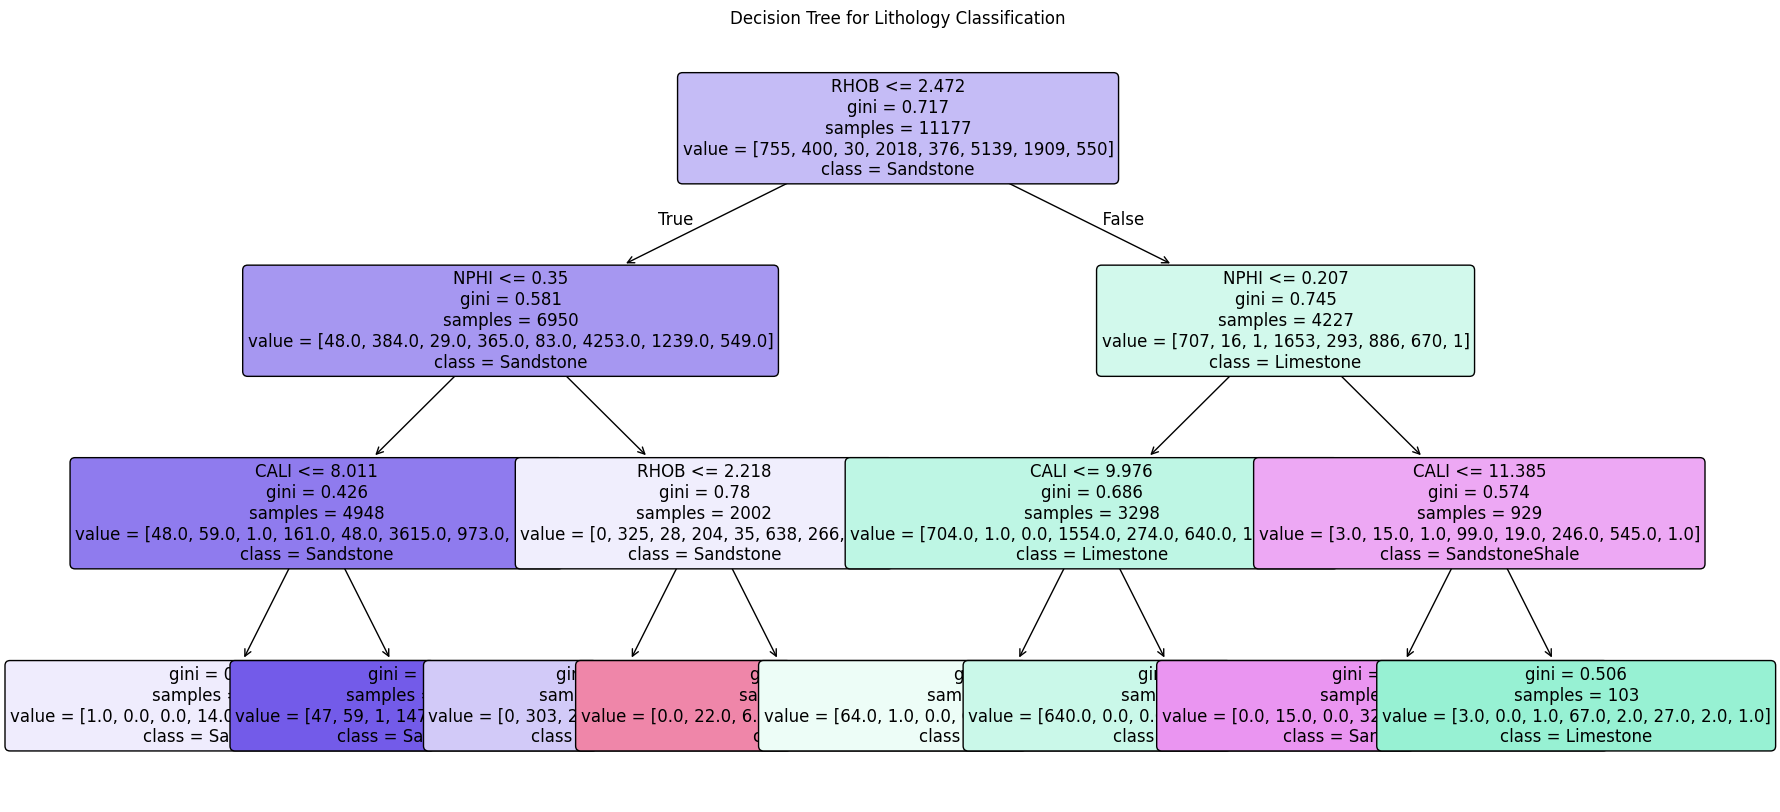

In [17]:
# Tree plot
from sklearn import tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
tree.plot_tree(DTModel, feature_names=feature_names, class_names=class_names, 
               filled=True, rounded=True, fontsize=12)
plt.title("Decision Tree for Lithology Classification")
plt.show()

### Inference

In [21]:
prediction = DTModel.predict(X_test)
print(prediction)

['Sandstone' 'Sandstone' 'Sandstone' ... 'Sandstone' 'Sandstone'
 'Limestone']


In [22]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

Actual_Labels = y_test
Predicted_Labels = prediction
##Create the Basic Confusion Matrix
My_Conf_Mat = confusion_matrix(Actual_Labels, Predicted_Labels)
print(My_Conf_Mat)

[[   0    0    0  175    0   14    0    0]
 [   0    0    0    1    0   95    2    2]
 [   0    0    0    0    0    6    0    1]
 [   0    0    0  408    0   80    5   12]
 [   0    0    0   62    0   23    8    1]
 [   0    0    0  168    0 1053   49   15]
 [   0    0    0   31    0  286  142   18]
 [   0    0    0    1    0   27    0  110]]


#### Confusion Matrix

Text(50.72222222222221, 0.5, 'Predicted')

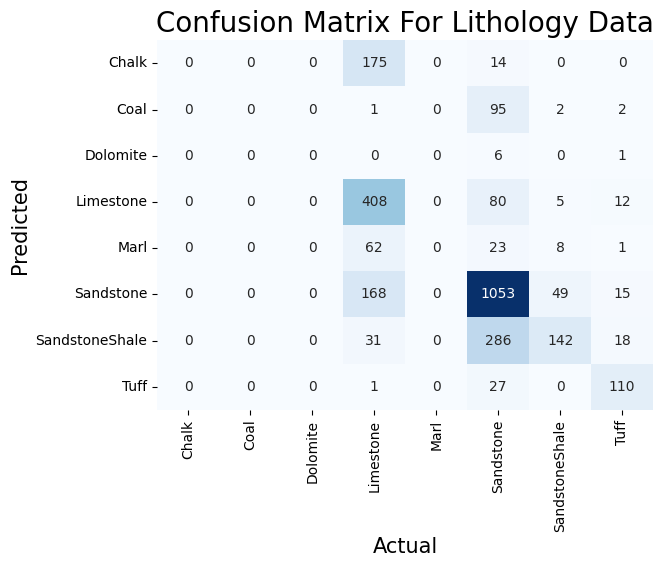

In [30]:
import seaborn as sns

##Create the fancy CM using Seaborn
sns.heatmap(My_Conf_Mat, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, 
            yticklabels=class_names, cbar=False)

plt.title("Confusion Matrix For Lithology Data",fontsize=20)
plt.xlabel("Actual", fontsize=15)
plt.ylabel("Predicted", fontsize=15)

# plt.savefig("seaborn_plot.jpg")
# plt.close()